In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils import PortfolioConfig, build_model_arrays, choose_value_maximizer
from numerical_tools import gauss_hermite_multinormal
from model1 import (
    solve_model_coefficients,
    compute_policy_grid_local,
    get_value_maximizer,
    transition_next_state,
)

np.set_printoptions(precision=5, suppress=True)

# Replication

#### Figure 1

In [2]:
cfg_struct = PortfolioConfig()
cfg_struct.n = (7, 7, 5, 21)
cfg_struct.q = 41
cfg_struct.qf = 21
cfg_struct.value_backend = "numba"
cfg_struct.m = (5, 5)
cfg_struct.T = 19


cfg_struct.t1 = 1
cfg_struct.smaxv =(540.0, 3540.0, 2000.0, 6_000_000.0)
cfg_struct.sminv = (230.0, 500.0, 400.0, 0.0)

# Solve model 
copt_local = solve_model_coefficients(cfg_struct)
W = np.array([1_000_000.0, 500_000.0, 350_000.0])
policy = compute_policy_grid_local(copt_local, cfg_struct, t=0, Lt=600.0, Rt=365.0, wealth_levels=W)

P = policy["P"]
XP = policy["XP"]

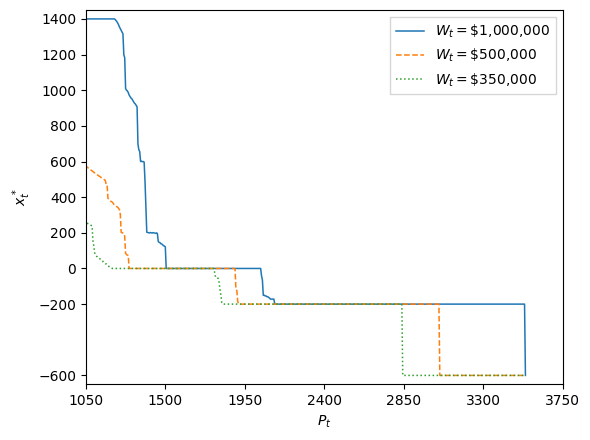

In [3]:
fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(P, XP[:, 0], "-", linewidth=1.1, label=r"$W_t = \$1{,}000{,}000$")
ax.plot(P, XP[:, 1], "--", linewidth=1.1, label=r"$W_t = \$500{,}000$")
ax.plot(P, XP[:, 2], ":", linewidth=1.1, label=r"$W_t = \$350{,}000$")


ax.set_xlim(1050, 3550)
ax.set_ylim(-650, 1450)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3300, 3750])
ax.set_yticks([-600, -200, 0, 200, 400, 600, 800, 1000, 1200, 1400])
ax.legend(loc="upper right", frameon=True, fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.savefig("Graphs/portfolio_policy_vs_price.png", dpi=300)
plt.show()

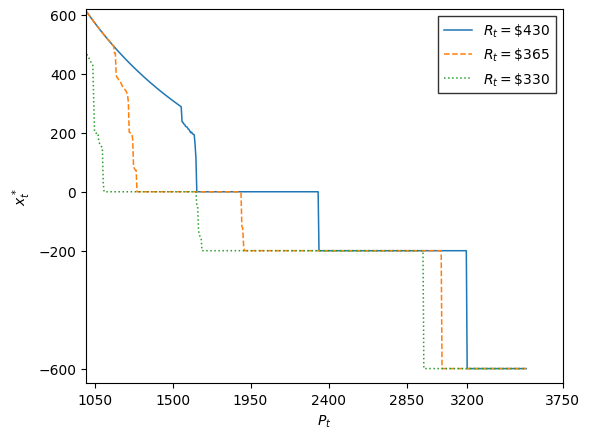

In [4]:
W_fixed = np.array([500_000.0])
R_values = [430.0, 365.0, 330.0]
styles = ["-", "--", ":"]
labels = [r"$R_t = \$430$", r"$R_t = \$365$", r"$R_t = \$330$"]

curves = []
P_plot = None
for Rt in R_values:
    policy_rt = compute_policy_grid_local(
        copt_local,
        cfg_struct,
        t=0,
        Lt=600.0,
        Rt=Rt,
        wealth_levels=W_fixed,
    )
    if P_plot is None:
        P_plot = policy_rt["P"]
    curves.append(policy_rt["XP"][:, 0])
#print(curves)
fig, ax = plt.subplots(figsize=(6.0, 4.5))
for y, style, label in zip(curves, styles, labels):
    ax.plot(P_plot, y, style, linewidth=1.1, label=label)
    if label == r"$R_t = \$365$":
        monkey = y  # Store this curve for later plotting

ax.set_xlim(1000, 3550)
ax.set_ylim(-650, 620)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3200, 3750])
ax.set_yticks([-600, -200, 0, 200, 400, 600])
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.savefig("Graphs/portfolio_policy_vs_price_Rt.png", dpi=300)
plt.show()


#### Table 3

In [5]:
rng = np.random.default_rng(42)
n_sims = 500
n_years = 10


cfg_struct = PortfolioConfig()
cfg_struct.n = (7, 7, 5, 21)
cfg_struct.q = 41
cfg_struct.qf = 21
cfg_struct.m = (5, 5)
cfg_struct.T = 19
cfg_struct.t1 = 1

copt_local = solve_model_coefficients(cfg_struct)

arrays = build_model_arrays(cfg_struct)
n = arrays["n"]
sminv = arrays["sminv"]
smaxv = arrays["smaxv"]
smin = arrays["smin"]
smax = arrays["smax"]
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
value_maximizer = get_value_maximizer(choose_value_maximizer(cfg_struct))
EgRM = 1.073826

scenario_specs = [
    ("Initial DFA = 0.7", 350_000.0),
    ("Initial DFA = 0.57", 500_000.0),
    ("Initial DFA = 0.14", 1_000_000.0),
]

all_series = []
for scenario_name, initial_wealth in scenario_specs:
    states = np.zeros((n_sims, 4), dtype=float)
    states[:, 0] = 365.0
    states[:, 1] = 1775.0
    states[:, 2] = 600.0
    states[:, 3] = initial_wealth
    exited = np.zeros(n_sims, dtype=bool)

    rows = [
        {
            "Expected net wealth ($)": states[:, 3].mean(),
            "Expected farm size (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": 0.0,
        }
    ]

    for year in range(1, n_years + 1):
        yr_idx = year - 1
        coeffs_t = copt_local[:, yr_idx]

        active_idx = np.where(~exited)[0]
        if active_idx.size > 0:
            active_states = states[active_idx]
            x_opt, _ = value_maximizer(
                active_states,
                coeffs_t,
                yr_idx,
                cfg_struct,
                n,
                sminv,
                smaxv,
                smin,
                smax,
                shock_nodes,
                shock_weights,
            )

            shocks = rng.multivariate_normal(
                mean=np.asarray(arrays["Ee"], dtype=float),
                cov=np.asarray(arrays["VarCov"], dtype=float),
                size=active_idx.size,
            )
            next_active = transition_next_state(
                active_states, x_opt, shocks, cfg_struct, sminv, smaxv
            )
            new_exit = (next_active[:, 2] < 1.0) | (next_active[:, 3] <= 0.0)
            states[active_idx] = next_active
            exited[active_idx[new_exit]] = True

        if np.any(exited):
            exited_idx = np.where(exited)[0]
            positive_wealth = states[exited_idx, 3] > 0.0
            states[exited_idx, 2] = 0.0
            states[exited_idx[positive_wealth], 3] = EgRM * states[exited_idx[positive_wealth], 3]
            states[exited_idx[~positive_wealth], 3] = (1.0 + cfg_struct.rn) * states[exited_idx[~positive_wealth], 3]

        cumulative_exit = exited.mean()

        rows.append(
            {
                "Expected net wealth ($)": states[:, 3].mean(),
                "Expected farm size (acres)": states[:, 2].mean(),
                "Prob. of exiting farming": cumulative_exit,
            }
        )

    scenario_df = pd.DataFrame(rows, index=pd.Index(range(n_years + 1), name="Year t"))
    scenario_df.columns = pd.MultiIndex.from_product([[scenario_name], scenario_df.columns])
    all_series.append(scenario_df)


table5 = pd.concat(all_series, axis=1)

display_table5 = table5.copy()
for scenario_name, _ in scenario_specs:
    display_table5[(scenario_name, "Expected net wealth ($)")] = display_table5[(scenario_name, "Expected net wealth ($)")].map(lambda v: f"{v:,.0f}")
    display_table5[(scenario_name, "Expected farm size (acres)")] = display_table5[(scenario_name, "Expected farm size (acres)")].map(lambda v: f"{v:,.0f}")
    display_table5[(scenario_name, "Prob. of exiting farming")] = display_table5[(scenario_name, "Prob. of exiting farming")].map(lambda v: f"{v:.3f}")

print("Table 5. Simulation results of expected path and probabilities of exiting farming")
display(display_table5)


Table 5. Simulation results of expected path and probabilities of exiting farming


Initial DFA = 0.7                             \
       Expected net wealth ($) Expected farm size (acres)   
Year t                                                      
0                      350,000                        600   
1                      374,820                        600   
2                      399,147                        511   
3                      433,949                        485   
4                      471,061                        484   
5                      503,755                        498   
6                      556,993                        529   
7                      603,354                        543   
8                      659,201                        581   
9                      718,614                        613   
10                     764,629                        640   

                                     Initial DFA = 0.57  \
       Prob. of exiting farming Expected net wealth ($)   
Year t                                                    
0                         0.000                 500,000   
1                         0.000                 538,427   
2                         0.006                 583,060   
3                         0.016                 620,764   
4                         0.032                 661,380   
5                         0.048                 720,353   
6                         0.064                 775,173   
7                         0.086                 845,891   
8                         0.098                 939,163   
9                         0.110               1,036,676   
10                        0.144               1,136,920   

                                                            \
       Expected farm size (acres) Prob. of exiting farming   
Year t                                                       
0                             600                    0.000   
1                             600                    0.000   
2                             541                    0.000   
3                             548                    0.000   
4                             563                    0.000   
5                             596                    0.000   
6                             646                    0.000   
7                             699                    0.006   
8                             732                    0.008   
9                             781                    0.014   
10                            831                    0.018   

            Initial DFA = 0.14                             \
       Expected net wealth ($) Expected farm size (acres)   
Year t                                                      
0                    1,000,000                        600   
1                    1,088,859                        600   
2                    1,164,002                        763   
3                    1,243,864                        880   
4                    1,369,816                        973   
5                    1,484,942                      1,058   
6                    1,606,477                      1,142   
7                    1,765,178                      1,158   
8                    1,934,259                      1,178   
9                    2,067,609                      1,188   
10                   2,210,852                      1,207   

                                 
       Prob. of exiting farming  
Year t                           
0                         0.000  
1                         0.000  
2                         0.000  
3                         0.000  
4                         0.000  
5                         0.000  
6                         0.000  
7                         0.000  
8                         0.000  
9                         0.000  
10                        0.000

In [6]:

tex_path = "Tables/table5.tex"


metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "Expected farm size (acres)": r"\makecell{Expected farm\\size (acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}

table5_makecell = display_table5.copy()
table5_makecell.columns = pd.MultiIndex.from_tuples(
    [(top, metric_makecell.get(sub, sub)) for top, sub in table5_makecell.columns]
)

table5_makecell.to_latex(
    tex_path,
    escape=False,
    multicolumn=True,
    multirow=True,
    index=True
)

print(f"Saved LaTeX table to {tex_path}")

Saved LaTeX table to Tables/table5.tex


#### Table 4 without mutual

In [7]:

cfg_table7 = PortfolioConfig()
cfg_table7.theta = 1.0
cfg_table7.value_backend = "numba"
cfg_table7.n = (7, 7, 5, 21)
cfg_table7.q = 41
cfg_table7.qf = 21
cfg_table7.m = (5, 5)
cfg_table7.T = 19
cfg_table7.t1 = 1

copt_table7 = solve_model_coefficients(cfg_table7)
arrays = build_model_arrays(cfg_table7)
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
value_maximizer = get_value_maximizer(choose_value_maximizer(cfg_table7))

def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)

def resulting_dfa_after_trade(P, L, W, x, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    lafa12f = (W - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, _ = value_maximizer(
            state,
            copt_table7[:, 0],
            0,
            cfg_table7,
            arrays["n"],
            arrays["sminv"],
            arrays["smaxv"],
            arrays["smin"],
            arrays["smax"],
            shock_nodes,
            shock_weights,
        )
        x_star = float(x_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star),
            }
        )

table7_without_mutual = pd.DataFrame(rows)
display_table7 = table7_without_mutual.copy()
display_table7["Net wealth ($)"] = display_table7["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7["Debt-to-farm-asset ratio"] = display_table7["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7["Optimal farmland transaction (acres)"] = display_table7["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7["Resulting debt-to-farm-asset ratio"] = display_table7["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7 - Model without mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7)


Table 7 - Model without mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,0.41
1,1500,"600,000",0.41,0,0.41
2,1500,"1,000,000",0.01,0,0.01
3,1775,"400,000",0.66,-200,0.49
4,1775,"600,000",0.49,-200,0.23
5,1775,"1,000,000",0.14,0,0.14


#### Table 5 

In [8]:
rng = np.random.default_rng(42)
n_sims = 500
n_years = 10

cfg_table8_nomut = PortfolioConfig()
cfg_table8_nomut.n = (7, 7, 5, 21)
cfg_table8_nomut.value_backend = "numba"
cfg_table8_nomut.q = 41
cfg_table8_nomut.qf = 21
cfg_table8_nomut.m = (5, 5)
cfg_table8_nomut.theta = 1.0
cfg_table8_nomut.T = 19
cfg_table8_nomut.t1 = 1

print(f"Solving no-mutual coefficients with q={cfg_table8_nomut.q}, qf={cfg_table8_nomut.qf}...")
copt_table8_nomut = solve_model_coefficients(cfg_table8_nomut)
print("Done solving.")

arrays = build_model_arrays(cfg_table8_nomut)
n = arrays["n"]
sminv = arrays["sminv"]
smaxv = arrays["smaxv"]
smin = arrays["smin"]
smax = arrays["smax"]
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
value_maximizer = get_value_maximizer(choose_value_maximizer(cfg_table8_nomut))

initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0
states[:, 1] = 1775.0
states[:, 2] = 600.0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    yr_idx = year - 1
    coeffs_t = copt_table8_nomut[:, yr_idx]

    active_mask = (states[:, 2] >= (sminv[2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]
    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]
        x_opt, _ = value_maximizer(
            active_states,
            coeffs_t,
            yr_idx,
            cfg_table8_nomut,
            n,
            sminv,
            smaxv,
            smin,
            smax,
            shock_nodes,
            shock_weights,
        )

        shocks = rng.multivariate_normal(
            mean=np.asarray(arrays["Ee"], dtype=float),
            cov=np.asarray(arrays["VarCov"], dtype=float),
            size=active_idx.size,
        )
        next_active = transition_next_state(
            active_states, x_opt, shocks, cfg_table8_nomut, sminv, smaxv
        )
        next_states[active_idx] = next_active

    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = 1.073826 * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg_table8_nomut.rn) * next_states[out_idx[~positive_wealth], 3]

    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )

table8_without_mutual = pd.DataFrame(summary_rows)
display_table8_without_mutual = table8_without_mutual.copy()
display_table8_without_mutual["Expected net wealth ($)"] = display_table8_without_mutual["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table8_without_mutual["St. dev. of net wealth ($)"] = display_table8_without_mutual["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
display_table8_without_mutual["Expected farmland (acres)"] = display_table8_without_mutual["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
display_table8_without_mutual["Prob. of exiting farming"] = display_table8_without_mutual["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")

print("Table 8-style simulation - Model without mutual fund")
display(display_table8_without_mutual)

Solving no-mutual coefficients with q=41, qf=21...
Done solving.
Table 8-style simulation - Model without mutual fund


,Year,Expected net wealth ($),St. dev. of net wealth ($),Expected farmland (acres),Prob. of exiting farming
0,0,"1,000,000",-,600,0.000
1,1,"1,063,820","140,345",600,0.000
2,2,"1,126,407","204,423",616,0.000
3,3,"1,211,066","260,735",673,0.000
4,4,"1,299,291","347,838",745,0.000
5,5,"1,394,016","452,739",816,0.000
6,6,"1,520,042","558,679",880,0.000
7,7,"1,639,761","676,047",958,0.004
8,8,"1,767,063","768,900","1,045",0.004
9,9,"1,915,917","864,453","1,077",0.006


# No transaction costs

In [9]:

cfg_struct = PortfolioConfig()
cfg_struct.n = (7, 7, 5, 21)
cfg_struct.q = 41
cfg_struct.qf = 21
cfg_struct.m = (5, 5)
cfg_struct.value_backend = "numba"
cfg_struct.T = 19
cfg_struct.tcs = 0.0
cfg_struct.tcb = 0.0
cfg_struct.t1 = 1
cfg_struct.smaxv =(540.0, 3540.0, 2000.0, 6_000_000.0)
cfg_struct.sminv = (230.0, 500.0, 400.0, 0.0)

copt_local = solve_model_coefficients(cfg_struct)
W = np.array([500_000.0])
policy = compute_policy_grid_local(copt_local, cfg_struct, t=0, Lt=600.0, Rt=365.0, wealth_levels=W)

P_cons = policy["P"]
XP_cons = policy["XP"]



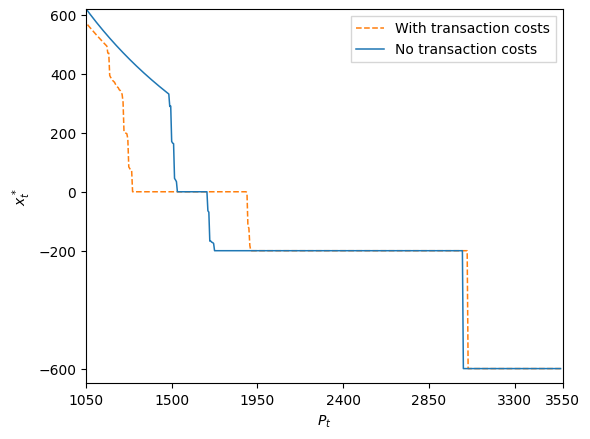

In [10]:
fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(P_cons, monkey, "--", linewidth=1.1, label=r"With transaction costs",color="tab:orange")

ax.plot(P_cons, XP_cons[:, 0], "-", linewidth=1.1, label=r"No transaction costs", color="tab:blue")


ax.set_xlim(1050, 3550)
#ax.set_ylim(-650, 1450)
ax.set_ylim(-650, 620)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3300, 3550])
ax.set_yticks([-600, -200, 0, 200, 400, 600])
ax.legend(loc="upper right", frameon=True, fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.savefig("Graphs/portfolio_policy_vs_price_constrained.png", dpi=300)
plt.show()

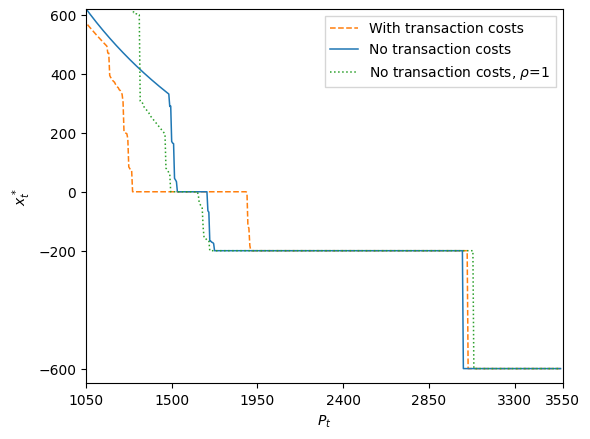

In [11]:

cfg_struct = PortfolioConfig()
cfg_struct.n = (7, 7, 5, 21)
cfg_struct.q = 41
cfg_struct.qf = 21
cfg_struct.m = (5, 5)
cfg_struct.T = 19
cfg_struct.value_backend = "numba"
cfg_struct.dau = 1.0
cfg_struct.tcs = 0.0
cfg_struct.tcb = 0.0
cfg_struct.t1 = 1
cfg_struct.smaxv =(540.0, 3540.0, 2000.0, 6_000_000.0)
cfg_struct.sminv = (230.0, 500.0, 400.0, 0.0)

copt_local = solve_model_coefficients(cfg_struct)
W = np.array([500_000.0])
policy = compute_policy_grid_local(copt_local, cfg_struct, t=0, Lt=600.0, Rt=365.0, wealth_levels=W)

P_cons_monk = policy["P"]
XP_cons_monk = policy["XP"]


fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(P_cons, monkey, "--", linewidth=1.1, label=r"With transaction costs",color="tab:orange")

ax.plot(P_cons, XP_cons[:, 0], "-", linewidth=1.1, label=r"No transaction costs", color="tab:blue")
ax.plot(P_cons_monk, XP_cons_monk[:, 0], ":", linewidth=1.1, label=r"No transaction costs, $\rho$=1", color="tab:green")

ax.set_xlim(1050, 3550)
#ax.set_ylim(-650, 1450)
ax.set_ylim(-650, 620)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3300, 3550])
ax.set_yticks([-600, -200, 0, 200, 400, 600])
ax.legend(loc="upper right", frameon=True, fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.savefig("Graphs/portfolio_policy_vs_price_constrained_with_rho.png", dpi=300)
plt.show()